### =============================================================================
### HOUSE PRICE PREDICTION - MODEL TRAINING & EVALUATION
### =============================================================================
### Author: Beksultan a.k.a rsuvbe
### Date: 23.03.2026
### Description: Preprocessing, training Linear Regression model, and evaluation
### =============================================================================



Data loaded: 1460 rows x 81 columns
Feature shape: (1460, 79)
Target shape: (1460,)

TARGET VARIABLE TRANSFORMATION
Original SalePrice - Mean: $180,921, Skew: 1.88
Log-transformed    - Mean: 12.02, Skew: 0.12


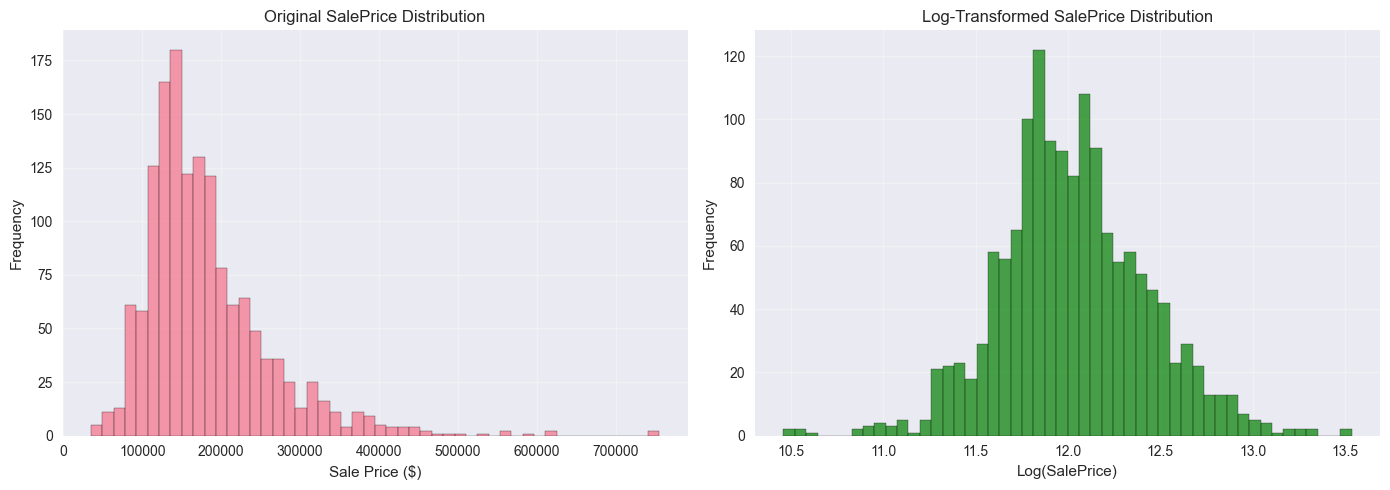

C:\Users\Бексултан\AppData\Local\Temp\ipykernel_16244\3199406538.py:75: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()



Numeric columns: 36
Cateforical columns: 43
Preprocessing pipeline created

Train set: 1168 samples
Validation set: 292 samples

Processed train shape: (1168, 301)
Processed validation set: (292, 301)
Total feature after preprocessing: 301

LINEAR REGRESSION MODEL
Model trained successfully

TRAIN SET:
 RMSE: $17,372
 MAE: $10,986
 R^2: 0.9494

VALIDATION SET:
 RMSE: $22,902
 MAE: $15,076
 R^2: 0.9316
OVERFITTING CHECK
Model generelizes well
 R^2 difference: 0.0178


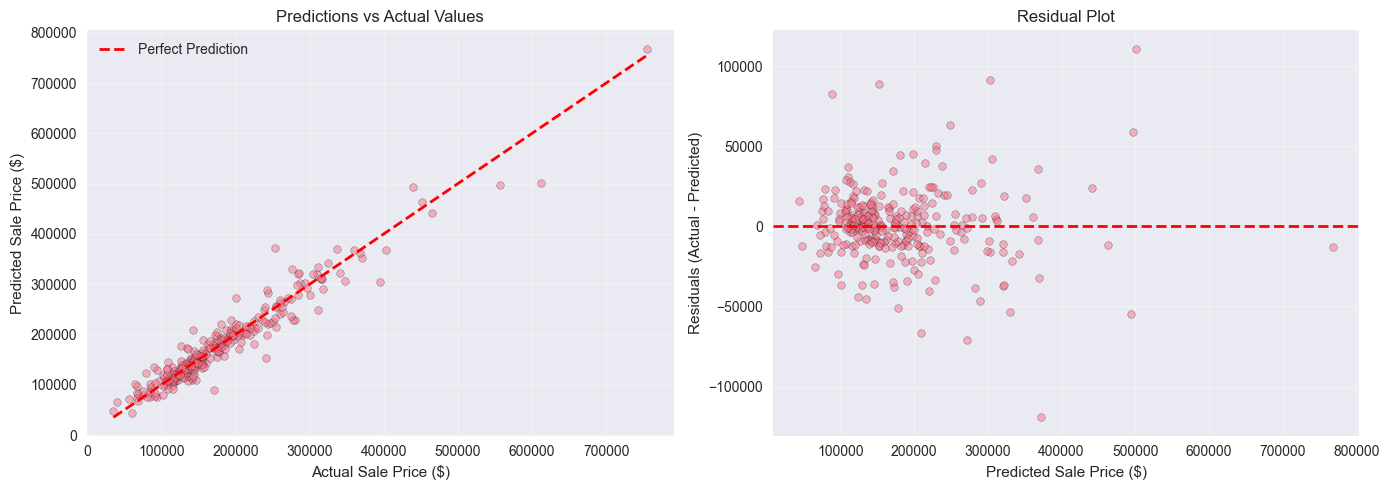

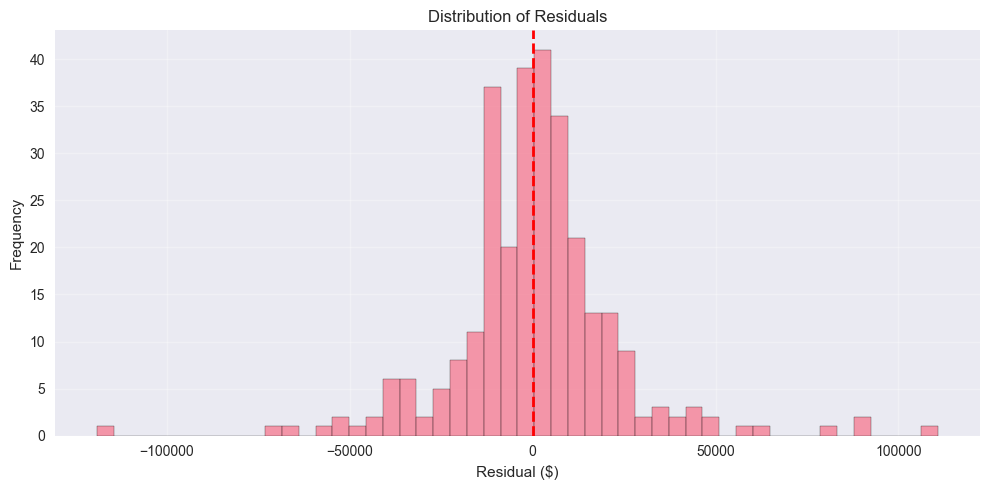


TOP MOST IMPORTANT FEATURES
         feature  coefficients  abs_coefficients
  PoolQC_missing      1.958709          1.958709
RoofMatl_ClyTile     -1.518678          1.518678
       PoolQC_Gd     -0.977033          0.977033
 Condition2_PosN     -0.768340          0.768340
       PoolQC_Fa     -0.695401          0.695401
  RoofMatl_Metal      0.346725          0.346725
Condition2_Feedr      0.344743          0.344743
 Condition2_RRAe     -0.325510          0.325510
 Condition2_PosA      0.324344          0.324344
  Functional_Sev     -0.314507          0.314507
   GarageQual_Ex      0.305939          0.305939
   RoofMatl_Roll      0.287725          0.287725
       PoolQC_Ex     -0.286275          0.286275
MSZoning_C (all)     -0.265347          0.265347
MiscFeature_TenC      0.262338          0.262338
   GarageCond_Ex     -0.251269          0.251269
  RoofStyle_Shed      0.232975          0.232975
RoofMatl_WdShngl      0.230206          0.230206
RoofMatl_WdShake      0.224567          

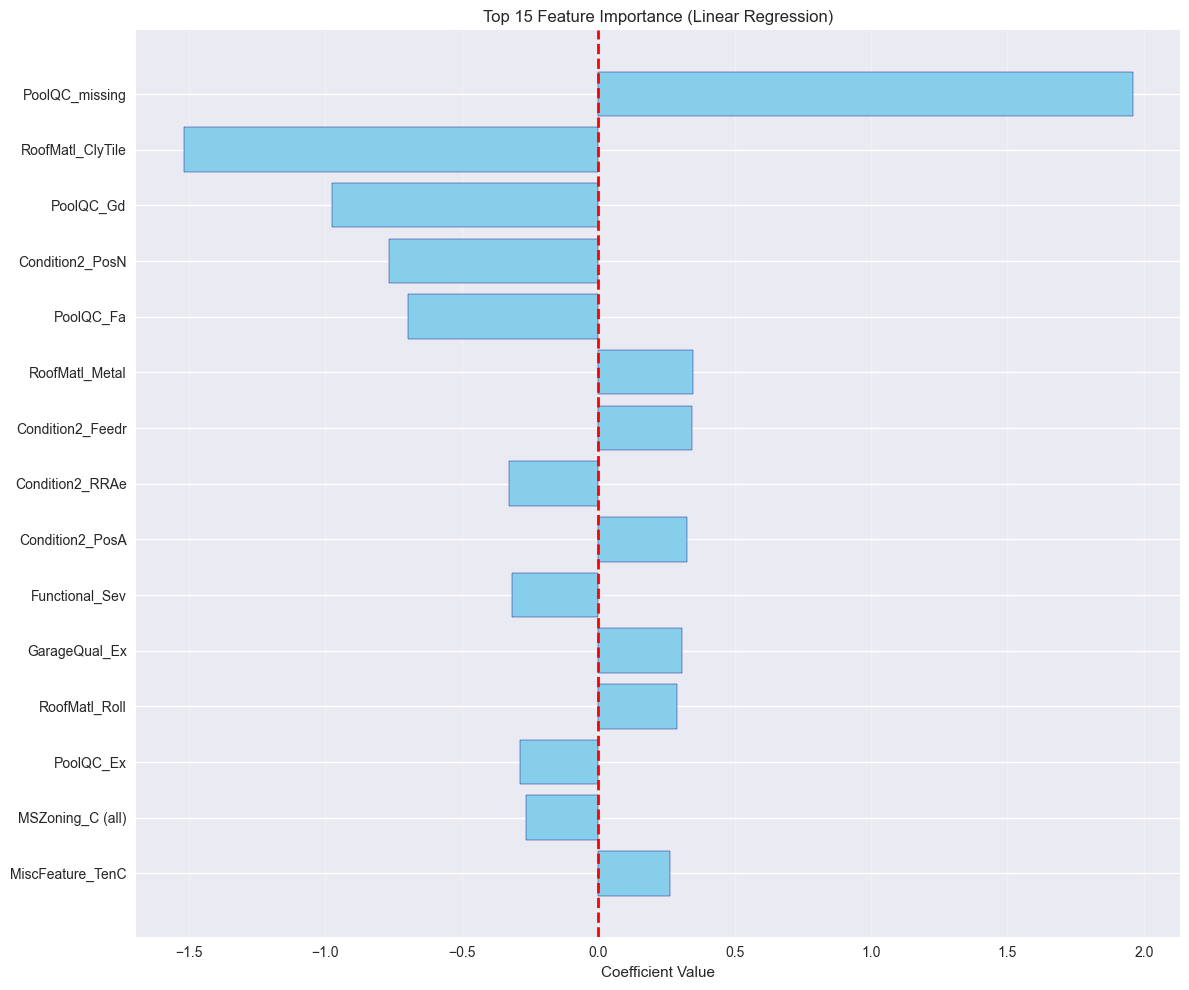


TRYING REGULARIZATION (Ridge & Lasso)

Ridge Regression (a=10)
  RMSE: $25,107
  R^2:   0.9178

Lasso Regression (a=0.001): 
  RMSE: $25,122
  R^2:   0.9177
  Features zeroed: 216 out of 301

MODEL COMPARISON
            Model         RMSE       R2
Linear Regression 22902.142119 0.931619
            Ridge 25106.744014 0.917820
            Lasso 25122.227347 0.917718

SAVING MODEL AND ARTIFACTS
Best model saved: LinearRegression
Preprocessor saved
Metrics saved to results/metrics.json


In [ ]:

# # 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
import joblib
import os 
import json

# 1. Plot Settings 
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 2. Load Data

# Loading training data

train_df = pd.read_csv('../data/train.csv')

print(f"Data loaded: {train_df.shape[0]} rows x {train_df.shape[1]} columns")

X = train_df.drop(['SalePrice', 'Id'], axis = 1)
y = train_df['SalePrice']

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")

## 3. Target Variable Transformation

# Log transformation (due to high skewness: 1.88)

print("\n" + "="*60)
print("TARGET VARIABLE TRANSFORMATION")
print("="*60)

y_log = np.log1p(y)

print(f"Original SalePrice - Mean: ${y.mean():,.0f}, Skew: {y.skew():.2f}")
print(f"Log-transformed    - Mean: {y_log.mean():.2f}, Skew: {y_log.skew():.2f}")

# Visualize 
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].hist(y, bins=50, edgecolor = 'black', alpha=0.7)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original SalePrice Distribution')
axes[0].grid(True,alpha=0.3)

axes[1].hist(y_log, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log(SalePrice)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed SalePrice Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/06_target_transformation.png', dpi = 150)
plt.show()


# # 4. Identify Column Types

# Identify numeric and categorical columns

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Cateforical columns: {len(categorical_cols)}")

# # 5. Create Preprocessing Pipeline

# Pipeline for Numeric features

numeric_transformer = Pipeline(steps=[
	('imputer', SimpleImputer(strategy='median')), 
	('scaler', StandardScaler()) 
])

# Pipeline for Categorical features

categorical_transformer = Pipeline(steps=[
	('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
	('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

#Combine preprocessing steps 
preprocessor = ColumnTransformer(transformers=[
	('num', numeric_transformer, numeric_cols),
	('cat', categorical_transformer, categorical_cols)
])

print("Preprocessing pipeline created")

# # 6.Split data into Train/Validation Sets

X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size = 0.2, random_state = 42, shuffle = True)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# # 7. Apply Preprocessing 

# Fit preprocessing on train data and transform both sets 

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print(f"\nProcessed train shape: {X_train_processed.shape}")
print(f"Processed validation set: {X_val_processed.shape}")

# Get feature names after preprocessing 
# Numeric features 	keep their names
# Categorical features are expanded by one-hot encoding 
numeric_features_names = numeric_cols

# Get categorical feature names after one-hot encoding
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
categorical_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()

all_feature_names = numeric_features_names + categorical_feature_names

print(f"Total feature after preprocessing: {len(all_feature_names)}")

# # 8. Train Linear Regression Model

print("\n" + "="*60)
print("LINEAR REGRESSION MODEL")
print("="*60)

#Create and train model 

model = LinearRegression()
model.fit(X_train_processed, y_train)

print("Model trained successfully")

# # 9. Evaluate Model Performance

# Make predictions

y_train_pred_log = model.predict(X_train_processed)
y_val_pred_log = model.predict(X_val_processed)

# Convert back to original scale

y_train_pred = np.expm1(y_train_pred_log)
y_val_pred = np.expm1(y_val_pred_log)
y_val_original = np.expm1(y_val)

# Calculate Metrics 

def calculate_metrics(y_true, y_pred, label):
	"""Calculate and print regression metrics"""
	mse = mean_squared_error(y_true, y_pred)
	rmse = np.sqrt(mse)
	mae = mean_absolute_error(y_true, y_pred)
	r2 = r2_score(y_true, y_pred)

	print(f"\n{label} SET:")
	print(f" RMSE: ${rmse:,.0f}")
	print(f" MAE: ${mae:,.0f}")
	print(f" R^2: {r2:.4f}")

	return {'rmse': rmse, 'mae': mae, 'r2': r2}

train_metrics = calculate_metrics(y_train_original := np.expm1(y_train), y_train_pred, "TRAIN")
val_metrics = calculate_metrics(y_val_original, y_val_pred, "VALIDATION")

#Check for overfitting

print("="*60)
print("OVERFITTING CHECK")
print("="*60)

r2_diff = train_metrics['r2'] - val_metrics['r2']
if r2_diff > 0.1:
	print(f"WARNING: Possible Overfitting Detected!")
	print(f" R^2 Difference: {r2_diff:.4f}")
else:
	print(f"Model generelizes well")
	print(f" R^2 difference: {r2_diff:.4f}")

# # 10. Visualize Results

#Plot 1: Predictions vs Actual 

fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].scatter(y_val_original, y_val_pred, alpha=0.5, edgecolors='k', s=30)
axes[0].plot([y_val_original.min(), y_val_original.max()],
						 [y_val_original.min(), y_val_original.max()],
						 'r--', linewidth=2, label = 'Perfect Prediction')
axes[0].set_xlabel('Actual Sale Price ($)')
axes[0].set_ylabel('Predicted Sale Price ($)')
axes[0].set_title('Predictions vs Actual Values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#Plot 2: Residuals

residuals = y_val_original - y_val_pred

axes[1].scatter(y_val_pred, residuals, alpha = 0.5, edgecolor = 'k', s = 30)
axes[1].axhline(y=0, color='r', linestyle ='--', linewidth = 2)
axes[1].set_xlabel('Predicted Sale Price ($)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/07_model_predictions.png', dpi = 150)
plt.show()

# Plot 3: Residual Distribution 
plt.figure(figsize=(10,5))
plt.hist(residuals, bins = 50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/08_residual_distribution.png', dpi = 150)
plt.show()

# # 11.Feature Importance Analysis 

# Get model coefficients

coefficients = model.coef_
intercept = model.intercept_

# Create DataFrame for feature importance

feature_importance = pd.DataFrame({
	'feature': all_feature_names,
	'coefficients': coefficients,
	'abs_coefficients': np.abs(coefficients)
	}).sort_values('abs_coefficients', ascending=False)

# Display top 20 most important features
print("\n" + "="*60)
print("TOP MOST IMPORTANT FEATURES")
print("="*60)
print(feature_importance.head(20).to_string(index=False))

## Visualize top 15 features 
plt.figure(figsize=(12,10))
top_15 = feature_importance.head(15)
plt.barh(top_15['feature'], top_15['coefficients'], color='skyblue', edgecolor= 'navy')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Importance (Linear Regression)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../results/09_feature_importance.png', dpi = 150)
plt.show()

## 12. Try Ridge and Lasso Regularization

print("\n" + "="*60)
print("TRYING REGULARIZATION (Ridge & Lasso)")
print("="*60)

#Ridge Regression (L2)

ridge = Ridge(alpha=10.0)
ridge.fit(X_train_processed, y_train)
ridge_pred_log = ridge.predict(X_val_processed)
ridge_pred = np.expm1(ridge_pred_log)

ridge_r2 = r2_score(y_val_original, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_val_original, ridge_pred))

print(f"\nRidge Regression (a=10)")
print(f"  RMSE: ${ridge_rmse:,.0f}")
print(f"  R^2:   {ridge_r2:.4f}")

# Lasso Regression (L1)

lasso = Lasso(alpha=0.001, max_iter = 10000)
lasso.fit(X_train_processed, y_train)
lasso_pred_log = lasso.predict(X_val_processed)
lasso_pred = np.expm1(lasso_pred_log)

lasso_r2 = r2_score(y_val_original, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_val_original, lasso_pred))

#Count zeroed features 

n_zeroed = np.sum(lasso.coef_ == 0)

print(f"\nLasso Regression (a=0.001): ")
print(f"  RMSE: ${lasso_rmse:,.0f}")
print(f"  R^2:   {lasso_r2:.4f}")
print(f"  Features zeroed: {n_zeroed} out of {len(lasso.coef_)}")

# Compare models

models_comparison = pd.DataFrame({
	'Model': ['Linear Regression', 'Ridge', 'Lasso'],
	'RMSE': [val_metrics['rmse'], ridge_rmse, lasso_rmse],
	'R2': [val_metrics['r2'], ridge_r2, lasso_r2]
})

print("\n"+"="*60)
print("MODEL COMPARISON")
print("="*60)
print(models_comparison.to_string(index=False))


# # 13. Save Model and Artifacts

print("\n" + "="*60)
print("SAVING MODEL AND ARTIFACTS")
print("="*60)

os.makedirs('../models', exist_ok=True)

best_model = ridge if ridge_r2 > val_metrics['r2'] else model
model_name = 'Ridge' if ridge_r2 > val_metrics['r2'] else 'LinearRegression'

joblib.dump(best_model, f'../models/{model_name.lower()}_model.pkl')
joblib.dump(preprocessor, '../models/preprocessor.pkl')

print(f"Best model saved: {model_name}")
print(f"Preprocessor saved")

#Save metrics

metrics = {
	'model': model_name,
	'train': {
		'rmse': float(train_metrics['rmse']),
		'mae':  float(train_metrics['mae']),
		'r2':   float(train_metrics['r2'])
	},
	'validation': {
		'rmse': float(val_metrics['rmse']),
		'mae':  float(val_metrics['mae']),
		'r2':   float(val_metrics['r2'])
	},
	'ridge': {
		'rmse': float(ridge_rmse),
		'r2':   float(ridge_r2)
	},
	'lasso': {
		'rmse': float(lasso_rmse),
		'r2':   float(lasso_r2),
		'features_zeroed': int(n_zeroed)
	}

}

with open('../results/metrics.json', 'w') as f:
		json.dump(metrics, f, indent=2)

print(f"Metrics saved to results/metrics.json")

